In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#select particular representative gauge
reg = 'SR'

if reg == 'CT':
    columnname = str(38)
    mask_size = '892'
    list_size = ['225','529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    mask_size = '961'
    list_size = ['228','550','961','1773','3669','6941']

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"


Catania

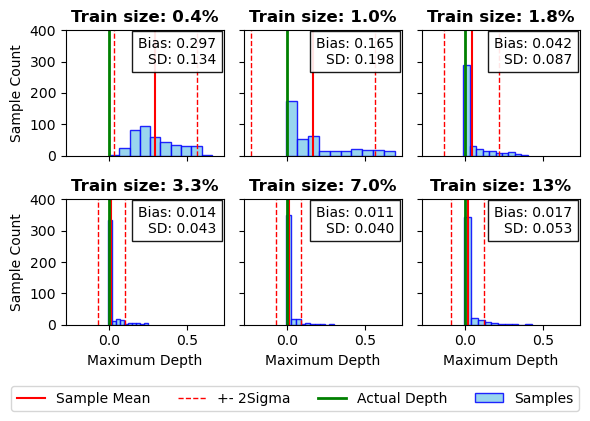

In [12]:
# Inputs
test_set = 1
event_id = 11000
site = 2

# For subplot layout
ncols = 3
nrows = int(np.ceil(len(list_size) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2), sharex=True, sharey=True)
axes = axes.flatten()
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 

for idx, train_size in enumerate(list_size):
    # Load data
    sample = np.load(f'{MLDir}/model/{reg}/multifoldMC/out/mc_samples_trainsize{train_size}_testsize{test_set}_direct.npy')
    tpe_table = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_testsize{test_set}.csv')

    # Extract sample and true/predicted
    pt_sc_sample = sample[:, event_id, site - 1]
    tpe_sc = tpe_table.iloc[[event_id]]
    true_val = tpe_sc[f'T{site}'].values[0]

    ax = axes[idx]

    # Mean, Median, Std
    mc_mean = np.mean(pt_sc_sample)
    mc_std = np.std(pt_sc_sample)
    mc_median = np.median(pt_sc_sample)
    
    # Bias and variance
    bias = np.abs(true_val - mc_mean)
    var = np.var(pt_sc_sample)
    sd = np.std(pt_sc_sample)

    # Plot indicators
    ax.axvline(mc_mean, color='r', label='Sample Mean')
    ax.axvline(mc_mean + 2*mc_std, color='r', linestyle='--', linewidth=1)
    ax.axvline(mc_mean - 2*mc_std, color='r', linestyle='--', linewidth=1,label='+- 2Sigma')
    ax.axvline(true_val, color='g', label='Actual Depth', linewidth=2)
    ax.hist(pt_sc_sample, bins=10, density=False, alpha=0.85, color='skyblue', label='Samples', edgecolor='blue')

    # Title & Text
    ax.set_title(f'Train size: {labels[idx]}', fontsize=12, fontweight='bold')
    ax.text(0.95, 0.95, f'Bias: {bias:.3f}\nSD: {sd:.3f}', 
            transform=ax.transAxes, ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.9))
    if idx == 0 or idx == 3:
        ax.set_ylabel('Sample Count')
    if idx >= 3:
        ax.set_xlabel('Maximum Depth')
    # ax.legend(loc='upper left', fontsize=10)
    ax.set_ylim(0, 400)

# Hide empty subplots
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

# Legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.01), fontsize=10)

# plt.suptitle(f'Distribution of Ensemble Samples for a site with True Value = {true_val:.3f}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'samples_{reg}_site{site}.png', dpi=300, bbox_inches='tight')
plt.show()


[6.266598694354692e-07, 9.613847101981674e-07, 1.3468424772691458e-06, 1.4576677989807745e-06, 1.535336056187323e-06, 1.521513543153501e-06]
[2.1211621222752507e-06, 2.285219499904051e-06, 2.340120307511372e-06, 2.369896036052983e-06, 2.2182813298680567e-06, 2.436262467608857e-06]
[4.044530736014689e-06, 5.290788693323066e-06, 4.292089904354428e-06, 3.896526570742301e-06, 3.477111369503646e-06, 3.562243606826082e-06]


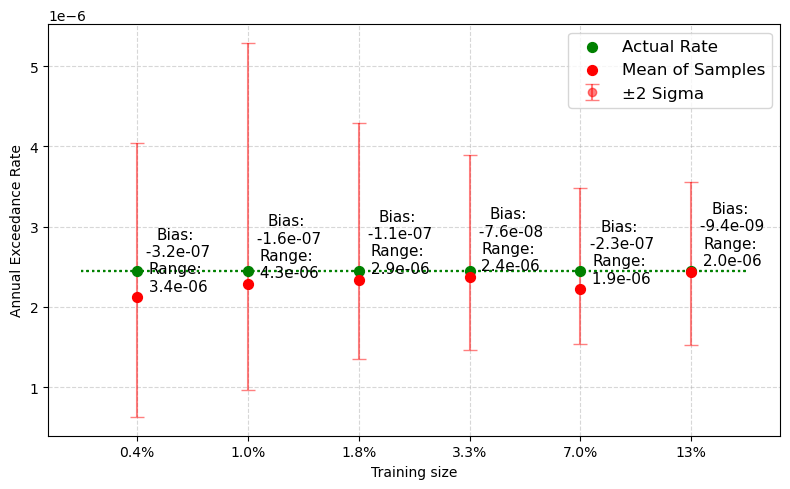

[4.592454934280899e-05, 7.088443862300491e-05, 7.357169146032357e-05, 7.233010017433227e-05, 7.205615975620352e-05, 7.071034903071592e-05]
[8.832260011098796e-05, 0.0001087031120224, 0.0001024058862227, 9.969346171517244e-05, 9.448203563056448e-05, 8.914405237925116e-05]
[0.0001563011152331, 0.0001717878788095, 0.0001480576390844, 0.0001415126447556, 0.0001281735604993, 0.0001176449444002]


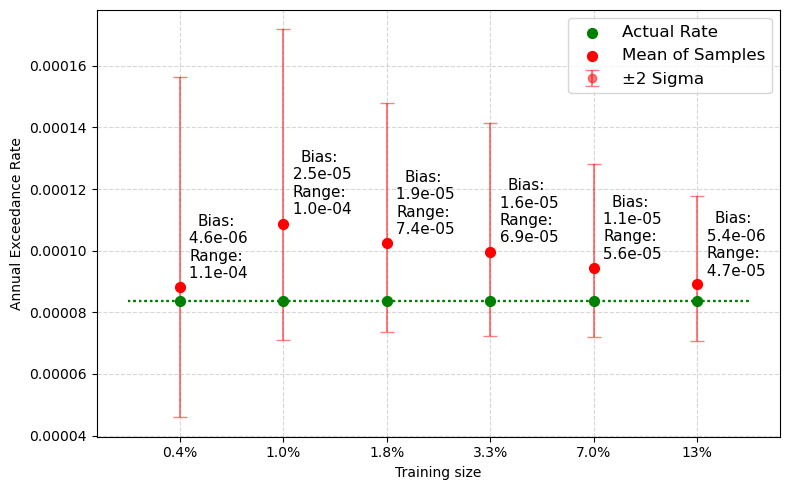

[3.0659316130067735e-07, 5.922619198869039e-07, 5.488903528220057e-07, 5.714282551885961e-07, 6.960750267296771e-07, 7.115189526598984e-07]
[1.386507579910632e-06, 1.3837839672563274e-06, 1.1786050640093974e-06, 1.1331418190074829e-06, 1.0878470943378862e-06, 1.1804880211427249e-06]
[2.938396021953486e-06, 2.514548126353249e-06, 1.7930680862630553e-06, 1.651669446904238e-06, 1.6758620595713678e-06, 1.6423163650126224e-06]


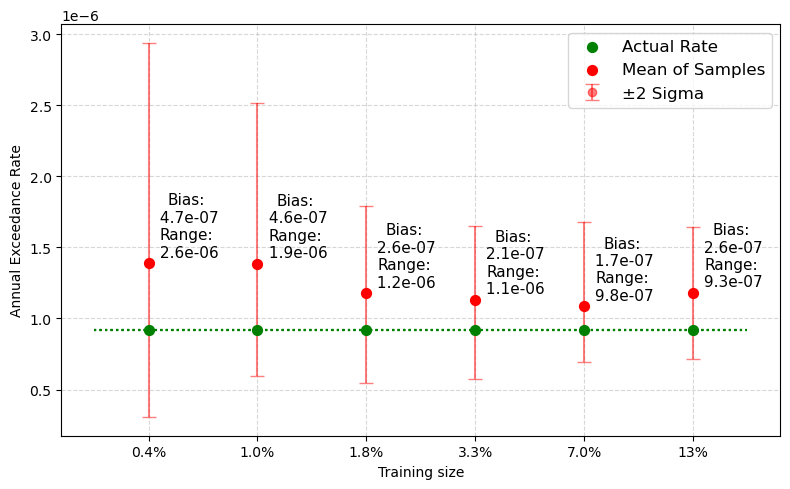

[1.2327184294209511e-06, 2.933792094888877e-06, 2.895642746965642e-06, 3.069014859585508e-06, 3.5795135915243054e-06, 3.2882637764771623e-06]
[3.512618060223924e-06, 6.421564477472876e-06, 6.586982275659135e-06, 5.869221466138151e-06, 6.031648178968044e-06, 5.70616994182312e-06]
[1.1892132245706475e-05, 1.6126482798505243e-05, 1.4895881238066666e-05, 1.0625095268697923e-05, 1.0405982674457092e-05, 9.612083962724184e-06]


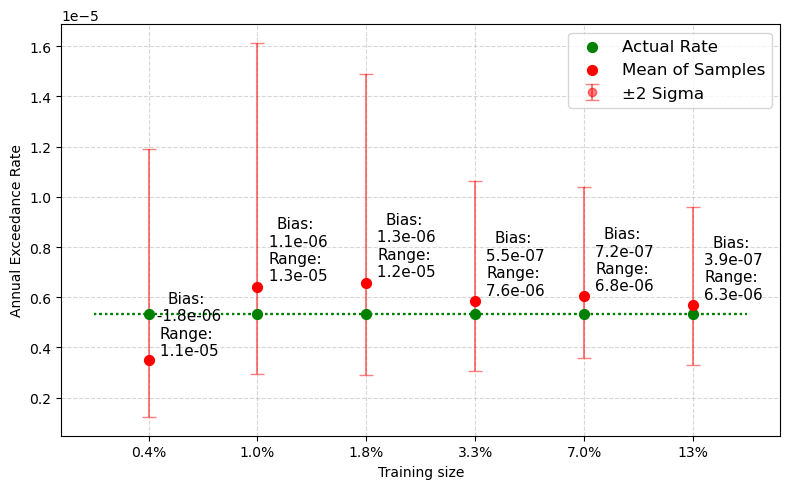

ValueError: x and y must be the same size

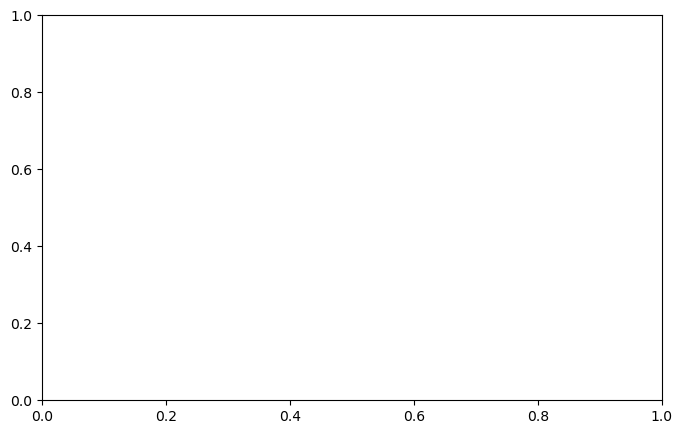

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']

# Configuration
for Site in range(1, 13):

    # Load the rate table for Site 2
    Table_rate = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/rate_error_table_{reg}_allsites.csv')
    Table_rate = Table_rate[Table_rate['Site'] == Site]



    # Prepare lists to store values
    true_vals = []
    means = []
    highs = []
    lows = []
    biases = []
    sigmas = []
    ranges = []

    for train_size in list_size:
        row = Table_rate[Table_rate['Train_size'] == int(train_size)]
        if row.empty:
            continue

        obs = row.iloc[0]['True']
        mu = row.iloc[0]['Pred']
        sigma = row.iloc[0]['Sigma']
        hi = row.iloc[0]['Pred_high']
        lo = row.iloc[0]['Pred_low']
        bias = row.iloc[0]['Bias']
        rangehilo = hi - lo

        true_vals.append(obs)
        means.append(mu)
        highs.append(hi)
        lows.append(lo)
        biases.append(bias)
        sigmas.append(sigma)
        ranges.append(rangehilo)

    # Convert to arrays for plotting
    x = np.arange(len(labels))

    # Create figure
    plt.figure(figsize=(8,5))

    # Plot true values
    plt.scatter(x, true_vals, color='green', label='Actual Rate', s=50, zorder=5)
    plt.hlines(true_vals, xmin=-0.5, xmax=len(x)-0.5, colors='green', linestyles='dotted', alpha=0.7)

    # Plot predicted means
    plt.scatter(x, means, color='red', label='Mean of Samples', s=50, zorder=5)

    # Plot ±2 sigma as error bars
    print(lows)
    print(means)
    print(highs)
    plt.errorbar(x, means, yerr=[np.array(means)-np.array(lows), np.array(highs)-np.array(means)],
                fmt='o', color='red', alpha=0.5, label='±2 Sigma', capsize=5)

    # Annotate biases and SDs
    for i in range(len(labels)):
        plt.text(x[i]+0.35, means[i]*1.02, f'Bias:\n {biases[i]:.1e}\nRange:\n {ranges[i]:.1e}',
                ha='center', va='bottom', fontsize=11)

    # Set labels and title
    plt.xticks(x, labels)
    plt.xlabel("Training size")
    plt.ylabel("Annual Exceedance Rate")
    # plt.yscale('log')
    # plt.title(f"Site {Site}: True vs Predicted AER with ±2 Sigma")
    plt.legend(fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(f'pdf_site{Site}_{reg}_combined.png', dpi=300)
    plt.show()


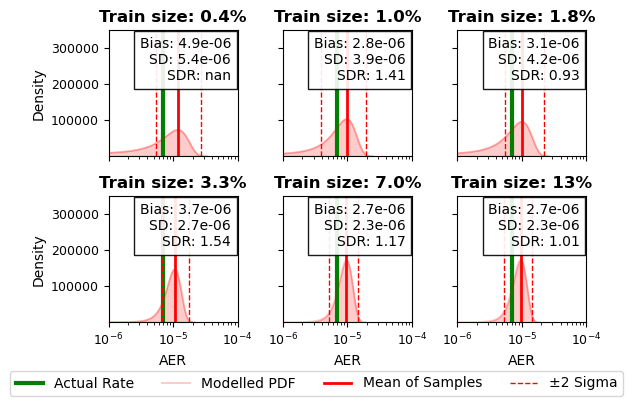

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Configuration
Site = 2
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']
ncols = 3
nrows = int(np.ceil(len(labels) / ncols))

# Create subplots
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2), sharex=True, sharey=True)
ax = ax.flatten()
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Load the rate table for Site 2
Table_rate = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/rate_error_table_{reg}_allsites.csv')
Table_rate = Table_rate[Table_rate['Site'] == Site]

prev_sd = None

for i, train_size in enumerate(list_size):
    row = Table_rate[Table_rate['Train_size'] == int(train_size)]
    if row.empty:
        continue

    obs = row.iloc[0]['True']
    mu = row.iloc[0]['Pred']
    sigma = row.iloc[0]['Sigma']
    hi = row.iloc[0]['Pred_high']
    lo = row.iloc[0]['Pred_low']
    bias = row.iloc[0]['Bias']
    var = sigma ** 2
    SDR = prev_sd / sigma if prev_sd is not None else np.nan
    prev_sd = sigma

    xmin = mu - 4 * sigma
    xmax = mu + 4 * sigma
    x = np.linspace(xmin, xmax, 10000)

    ax[i].axvline(obs, color='green', linestyle='-', label='Actual Rate', linewidth=3)
    ax[i].plot(x, norm.pdf(x, mu, sigma), color='r', label='Modelled PDF', alpha=0.2)
    ax[i].axvline(mu, color='r', linestyle='-', label='Mean of Samples', linewidth=2)
    ax[i].axvline(hi, color='r', linestyle='--', linewidth=1)
    ax[i].axvline(lo, color='r', linestyle='--', linewidth=1, label='±2 Sigma')
    ax[i].fill_between(x, norm.pdf(x, mu, sigma), color='r', alpha=0.2)

    # Annotate values with font size 10
    ax[i].text(0.95, 0.95, f'Bias: {bias:.1e}\nSD: {sigma:.1e}\nSDR: {SDR:.2f}',
               transform=ax[i].transAxes, ha='right', va='top', fontsize=10,
               bbox=dict(facecolor='white', alpha=0.9))

    ax[i].set_xscale('log')
    ax[i].set_title(f"Train size: {labels[i]}", fontsize=12, fontweight='bold')
    ax[i].tick_params(labelsize=9)
    if i % ncols == 0:
        ax[i].set_ylabel("Density", fontsize=10)
    if i >= ncols * (nrows - 1):
        ax[i].set_xlabel("AER", fontsize=10)

    # Set limits (adapt as needed for Site 2)
    ax[i].set_xlim(1e-6, 1e-4)
    ax[i].set_ylim(1000, 3.5e5)

# Hide any unused axes (if list_size < 6)
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

# Add legend once with fontsize 12
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'pdf_site{Site}_{reg}_250cm.png', dpi=300, bbox_inches='tight')
plt.show()


/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:1904: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/mnt/beegfs/nragu/tsunami/env/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:1904: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


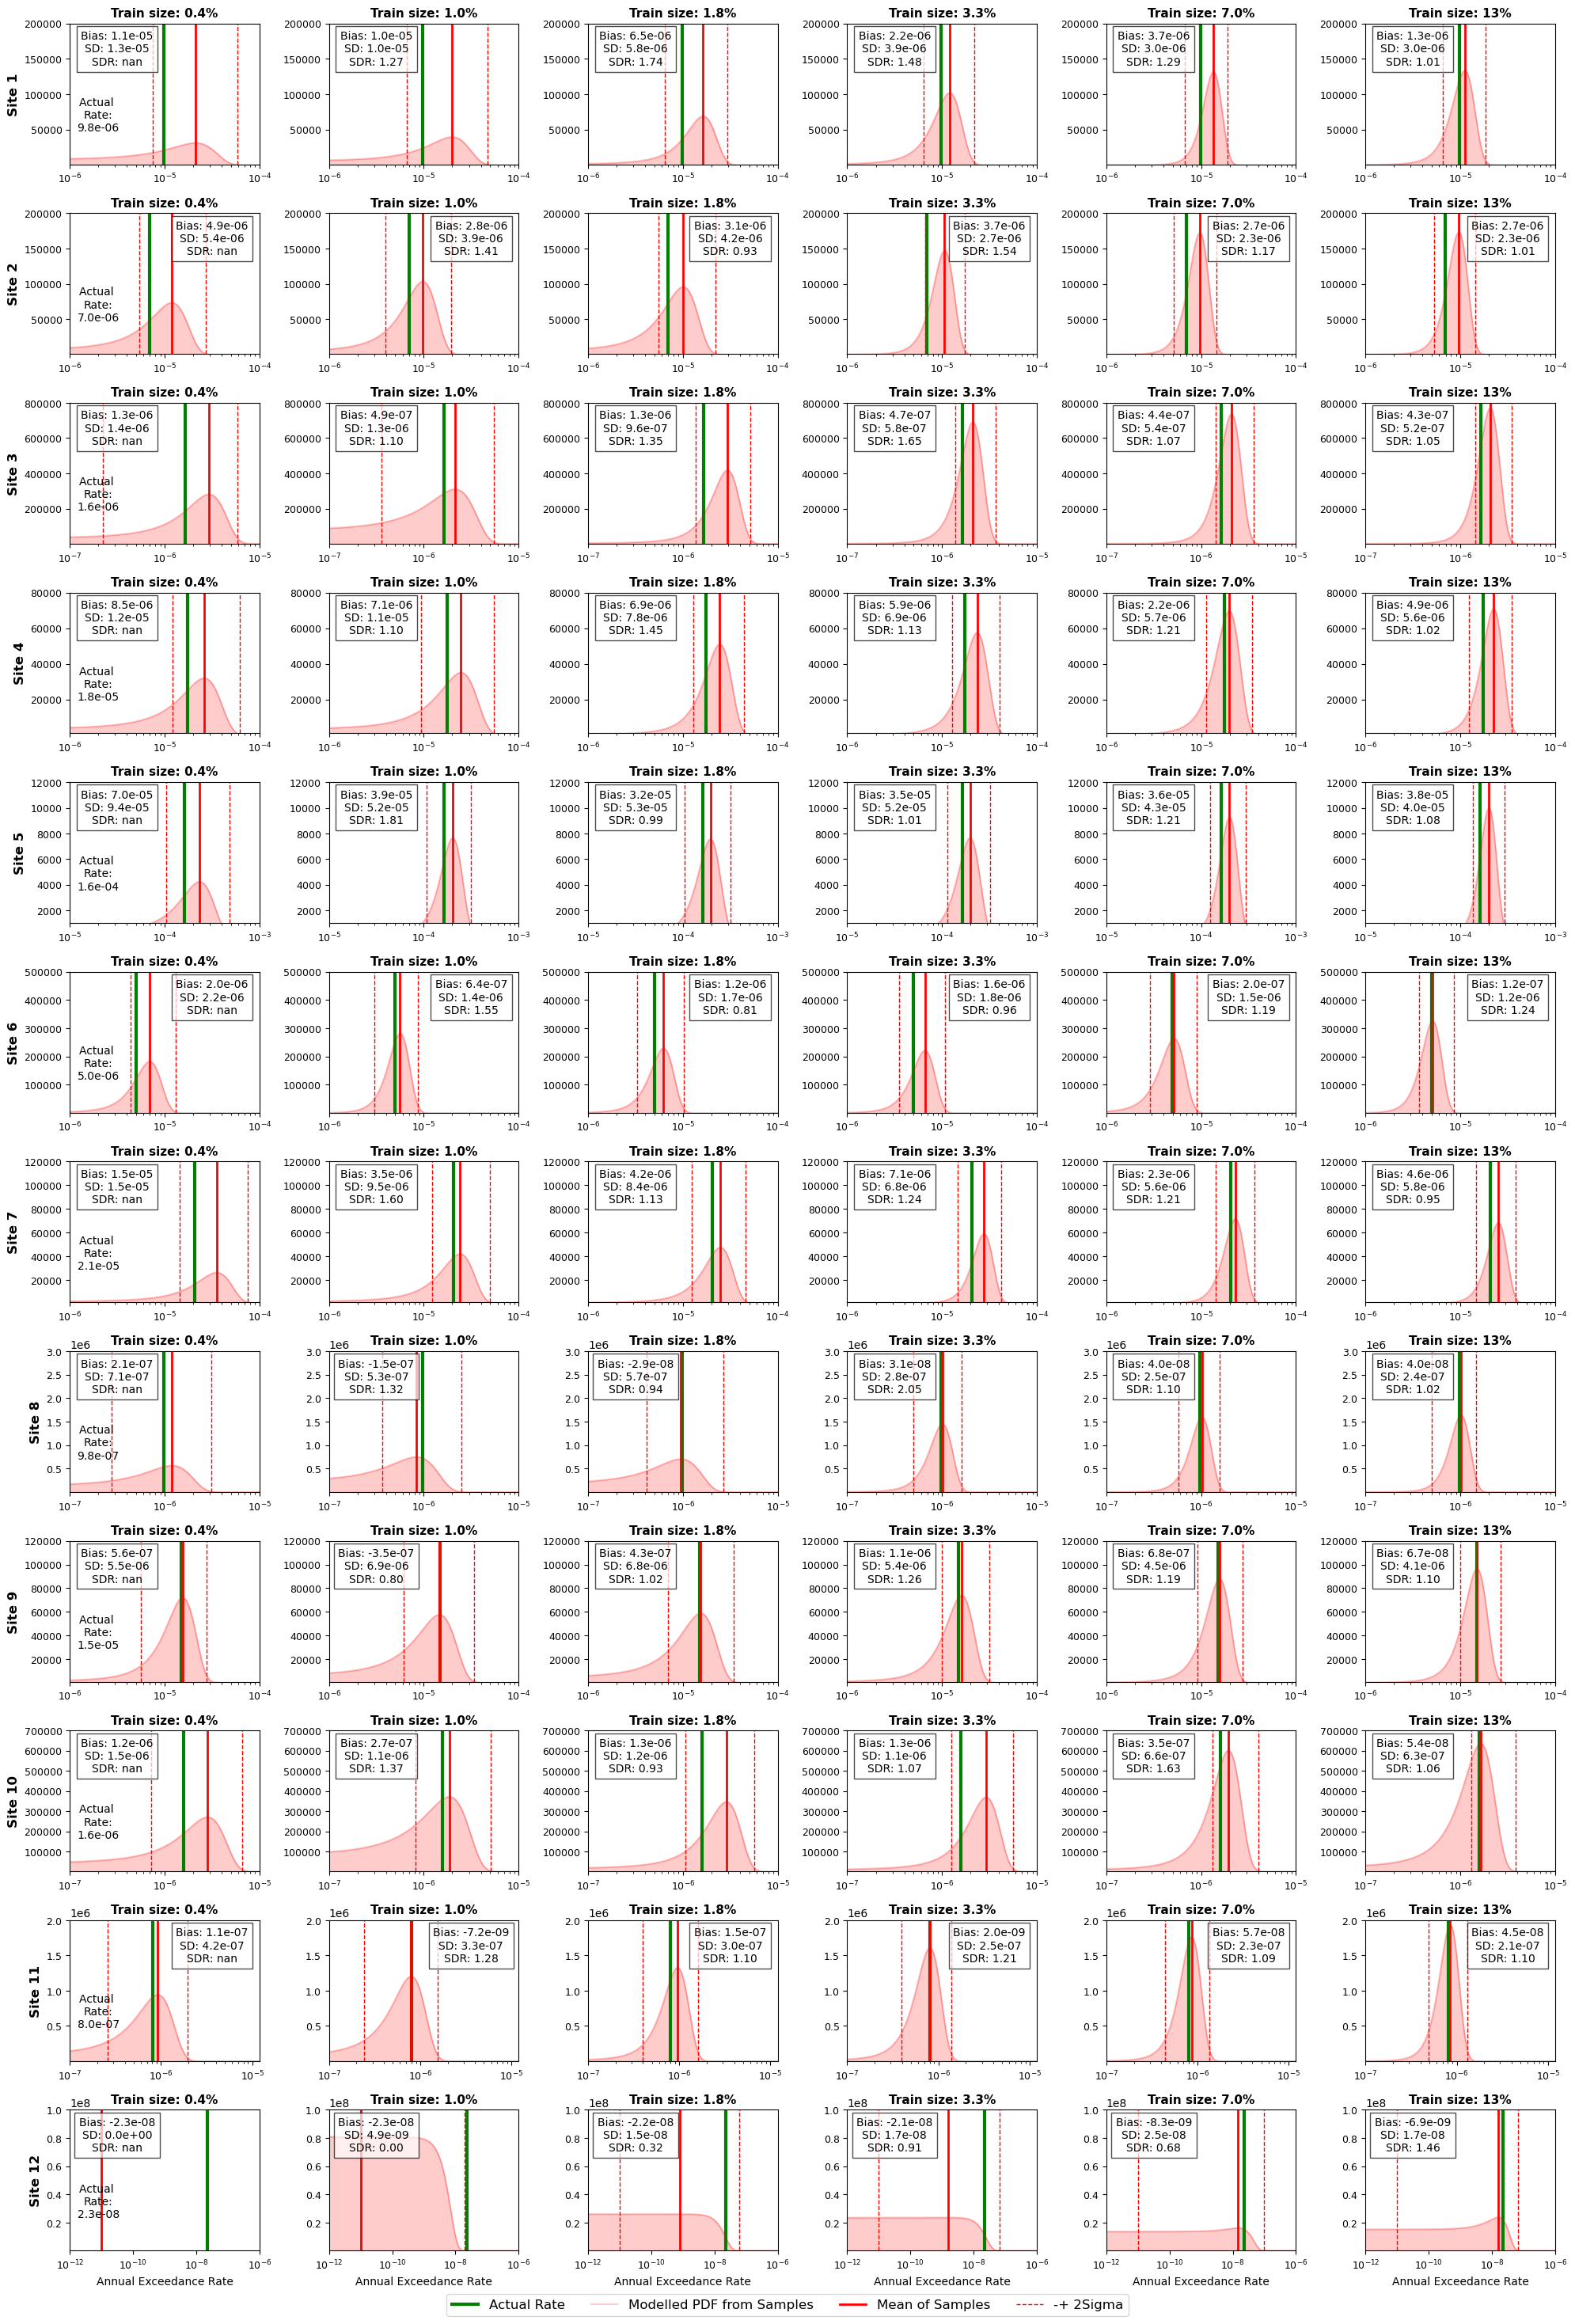

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Config
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']

fig, ax = plt.subplots(12, 6, figsize=(20, 30), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for Site in range(1, 13):
    j = Site - 1
    Table_rate = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/rate_error_table_{reg}_allsites.csv')
    Table_rate = Table_rate[Table_rate['Site'] == Site]

    prev_sd = None
    for i, train_size in enumerate(list_size):
        row = Table_rate[Table_rate['Train_size'] == int(train_size)]
        if row.empty:
            continue

        obs = row.iloc[0]['True']
        mu = row.iloc[0]['Pred']
        sigma = row.iloc[0]['Sigma']
        hi = row.iloc[0]['Pred_high']
        lo = row.iloc[0]['Pred_low']
        bias = row.iloc[0]['Bias']
        var = sigma ** 2
        SDR = prev_sd / sigma if prev_sd is not None else np.nan
        prev_sd = sigma

        # Plot distribution
        x = np.logspace(-15, -3, 10000)

        ax[j, i].axvline(obs, color='green', linestyle='-', label='Actual Rate',linewidth=3)
        ax[j, i].plot(x, norm.pdf(x, mu, sigma), color='r', label='Modelled PDF from Samples',alpha=0.2)
        ax[j, i].axvline(mu, color='r', linestyle='-', label='Mean of Samples',linewidth=2)
        ax[j, i].axvline(hi, color='r', linestyle='--', linewidth=1)
        ax[j, i].axvline(lo, color='r', linestyle='--', linewidth=1, label='-+ 2Sigma')
        ax[j, i].fill_between(x, norm.pdf(x, mu, sigma), color='r', alpha=0.2)

        # For first column, put label on left; for third row, put label on right
        if i == 0 :
            ax[j, i].text(0.15, 0.35, f'Actual \nRate:\n{obs:.1e}', transform=ax[j, i].transAxes, ha='center', va='center', fontsize=10)
        

        # Annotate bias, var, VR
        if j == 1 or j==10 or j==5:
            ax[j, i].text(0.75, 0.95, f'Bias: {bias:.1e}\nSD: {sigma:.1e}\nSDR: {SDR:.2f}', transform=ax[j, i].transAxes, ha='center', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
        else:
            ax[j, i].text(0.25, 0.95, f'Bias: {bias:.1e}\nSD: {sigma:.1e}\nSDR: {SDR:.2f}', transform=ax[j, i].transAxes, ha='center', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

        # Aesthetics
        ax[j, i].set_xscale('log')
        ax[j, i].set_title(f"Train size: {labels[i]}", fontsize=11,fontweight='bold')
        ax[j, i].tick_params(labelsize=9)

        # Axis labels
        if i == 0:
            ax[j, i].set_ylabel(f"Site {Site}", fontsize=12,fontweight='bold')
        if j == 11:
            ax[j, i].set_xlabel("Annual Exceedance Rate", fontsize=10)
        
        # Set x and y limits
        ax[j, i].set_xlim(1e-6, 1e-4)
        ax[j, i].set_ylim(1000, 2e5)

        if j == 2:
            ax[j, i].set_ylim(1000, 8e5)
            ax[j, i].set_xlim(1e-7, 1e-5)
        elif j == 3 :
            ax[j, i].set_ylim(1000, 8e4)
        elif j == 4:
            ax[j, i].set_xlim(1e-5, 1e-3)
            ax[j, i].set_ylim(1000, 1.2e4)
        elif j==5:
            ax[j, i].set_ylim(1000, 5e5)
        elif j==6:
            ax[j, i].set_xlim(1e-6, 1e-4)
            ax[j, i].set_ylim(1000, 1.2e5)
        elif j==7:
            ax[j, i].set_xlim(1e-7, 1e-5)
            ax[j, i].set_ylim(1000, 3e6)
        elif j == 8:
            ax[j, i].set_ylim(1000, 1.2e5)
        elif j == 9:
            ax[j, i].set_ylim(1000, 7e5)
            ax[j, i].set_xlim(1e-7, 1e-5)
        elif j == 10:
            ax[j, i].set_ylim(1000, 2e6)
            ax[j, i].set_xlim(1e-7, 1.2e-5)
        elif j == 11:
            ax[j, i].set_ylim(1000, 1e8)
            ax[j, i].set_xlim(1e-12, 1e-6)
            
# Legend once
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=12, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'pdf_allsites_{reg}_250cm.png', dpi=300, bbox_inches='tight')
plt.show()


Siracusa

In [15]:
#select particular representative gauge
reg = 'SR'

if reg == 'CT':
    columnname = str(38)
    mask_size = '892'
    list_size = ['225','529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    mask_size = '961'
    list_size = ['228','550','961','1773','3669','6941']

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"

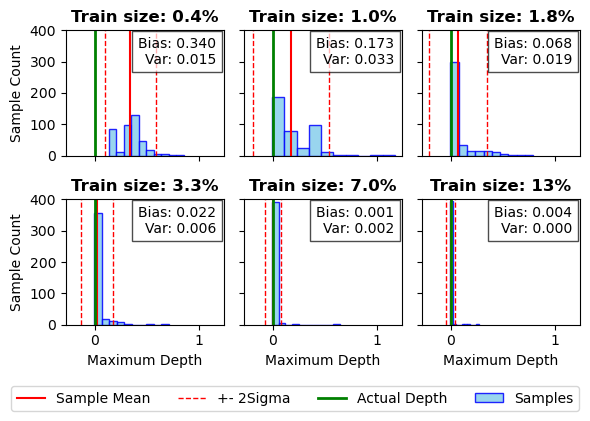

In [10]:
# Inputs
test_set = 1
event_id = 4000
site = 2

# For subplot layout
ncols = 3
nrows = int(np.ceil(len(list_size) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2), sharex=True, sharey=True)
axes = axes.flatten()
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 

for idx, train_size in enumerate(list_size):
    # Load data
    sample = np.load(f'{MLDir}/model/{reg}/multifoldMC/out/mc_samples_trainsize{train_size}_testsize{test_set}_direct.npy')
    tpe_table = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size[0]}_true_pred_er_testsize{test_set}.csv')

    # Extract sample and true/predicted
    pt_sc_sample = sample[:, event_id, site - 1]
    tpe_sc = tpe_table.iloc[[event_id]]
    true_val = tpe_sc[f'T{site}'].values[0]

    ax = axes[idx]

    # Mean, Median, Std
    mc_mean = np.mean(pt_sc_sample)
    mc_std = np.std(pt_sc_sample)
    mc_median = np.median(pt_sc_sample)
    
    # Bias and variance
    bias = np.abs(true_val - mc_mean)
    var = np.var(pt_sc_sample)

    # Plot indicators
    ax.axvline(mc_mean, color='r', label='Sample Mean')
    ax.axvline(mc_mean + 2*mc_std, color='r', linestyle='--', linewidth=1)
    ax.axvline(mc_mean - 2*mc_std, color='r', linestyle='--', linewidth=1,label='+- 2Sigma')
    ax.axvline(true_val, color='g', label='Actual Depth', linewidth=2)
    ax.hist(pt_sc_sample, bins=10, density=False, alpha=0.85, color='skyblue', label='Samples', edgecolor='blue')

    # Title & Text
    ax.set_title(f'Train size: {labels[idx]}', fontsize=12, fontweight='bold')
    ax.text(0.95, 0.95, f'Bias: {bias:.3f}\nVar: {var:.3f}', 
            transform=ax.transAxes, ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    if idx == 0 or idx == 3:
        ax.set_ylabel('Sample Count')
    if idx >= 3:
        ax.set_xlabel('Maximum Depth')
    # ax.legend(loc='upper left', fontsize=10)
    ax.set_ylim(0, 400)

# Hide empty subplots
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

# Legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.01), fontsize=10)

# plt.suptitle(f'Distribution of Ensemble Samples for a site with True Value = {true_val:.3f}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'samples_{reg}_site{site}.png', dpi=300, bbox_inches='tight')
plt.show()


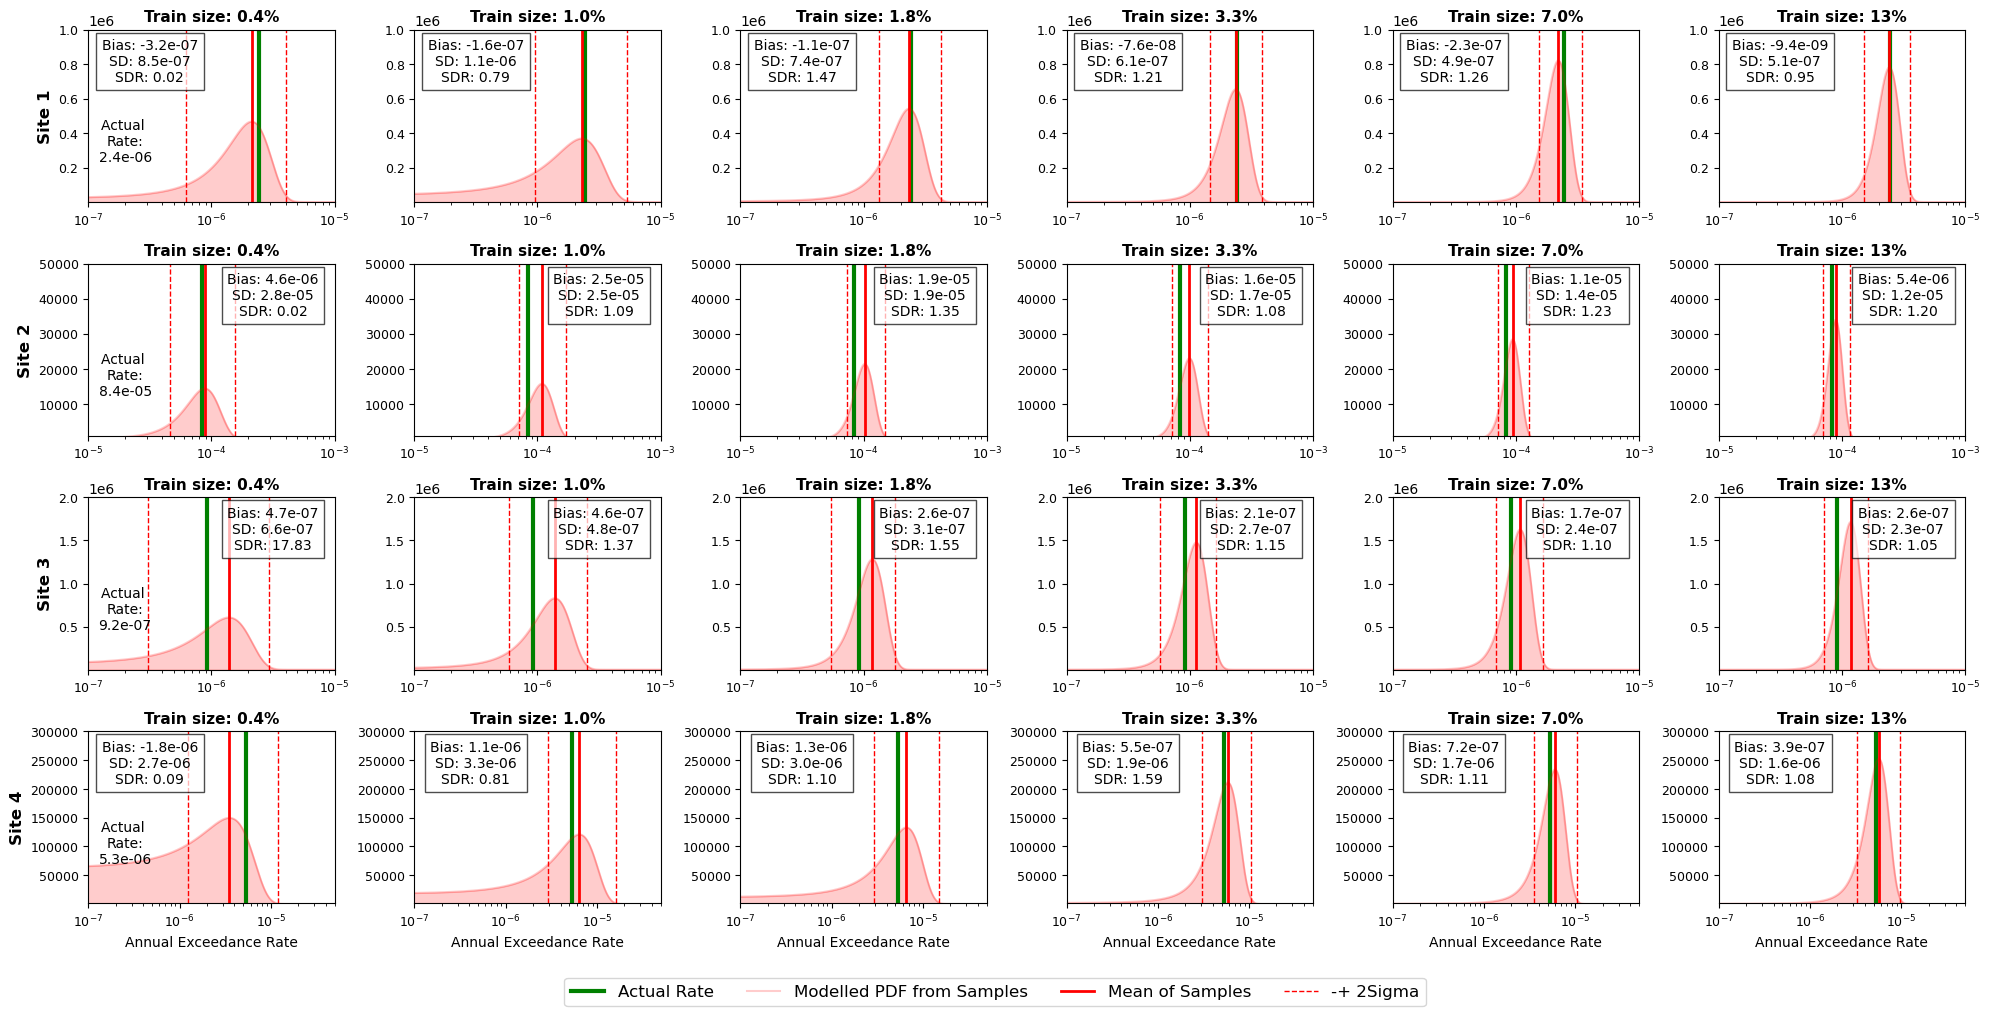

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Config
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%']

fig, ax = plt.subplots(4, 6, figsize=(20, 10), sharey=False, sharex=False)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for Site in range(1, 5):
    j = Site - 1
    Table_rate = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/rate_error_table_{reg}_allsites.csv')
    Table_rate = Table_rate[Table_rate['Site'] == Site]

    prev_var = None
    for i, train_size in enumerate(list_size):
        row = Table_rate[Table_rate['Train_size'] == int(train_size)]
        if row.empty:
            continue
        
        obs = row.iloc[0]['True']
        mu = row.iloc[0]['Pred']
        sigma = row.iloc[0]['Sigma']
        hi = row.iloc[0]['Pred_high']
        lo = row.iloc[0]['Pred_low']
        bias = row.iloc[0]['Bias']
        var = sigma ** 2
        SDR = prev_sd / sigma if prev_sd is not None else np.nan
        prev_sd = sigma

        # Plot distribution
        x = np.logspace(-8, -3, 10000)

        ax[j, i].axvline(obs, color='green', linestyle='-', label='Actual Rate',linewidth=3)
        ax[j, i].plot(x, norm.pdf(x, mu, sigma), color='r', label='Modelled PDF from Samples',alpha=0.2)
        ax[j, i].axvline(mu, color='r', linestyle='-', label='Mean of Samples',linewidth=2)
        ax[j, i].axvline(hi, color='r', linestyle='--', linewidth=1)
        ax[j, i].axvline(lo, color='r', linestyle='--', linewidth=1, label='-+ 2Sigma')
        ax[j, i].fill_between(x, norm.pdf(x, mu, sigma), color='r', alpha=0.2)

        # For first column, put label on left; for third row, put label on right
        if i == 0:
            ax[j, i].text(0.15, 0.35, f'Actual \nRate:\n{obs:.1e}', transform=ax[j, i].transAxes, ha='center', va='center', fontsize=10)

        # # Annotate bias, var, VR
        if j ==1 or j == 2:
            ax[j, i].text(0.75, 0.95, f'Bias: {bias:.1e}\nSD: {sigma:.1e}\nSDR: {SDR:.2f}', transform=ax[j, i].transAxes, ha='center', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
        else:
            ax[j, i].text(0.25, 0.95, f'Bias: {bias:.1e}\nSD: {sigma:.1e}\nSDR: {SDR:.2f}', transform=ax[j, i].transAxes, ha='center', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

        # Aesthetics
        ax[j, i].set_xscale('log')
        ax[j, i].set_title(f"Train size: {labels[i]}", fontsize=11,fontweight='bold')
        ax[j, i].tick_params(labelsize=9)

        # Axis labels
        if i == 0:
            ax[j, i].set_ylabel(f"Site {Site}", fontsize=12,fontweight='bold')
        if j == 3:
            ax[j, i].set_xlabel("Annual Exceedance Rate", fontsize=10)
        
        # Set x and y limits
        if j ==0:
            ax[j, i].set_xlim(1e-7, 1e-5)
            ax[j, i].set_ylim(1000, 1e6)
        elif j == 1:
            ax[j, i].set_xlim(1e-5, 1e-3)
            ax[j, i].set_ylim(1000, 5e4)
        if j == 2:
            ax[j, i].set_xlim(1e-7, 1e-5)
            ax[j, i].set_ylim(1000, 2e6)
        elif j == 3 :
            ax[j, i].set_xlim(1e-7, 5e-5)
            ax[j, i].set_ylim(1000, 3e5)

# Legend once
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=12, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'pdf_allsites_{reg}_250cm.png', dpi=300, bbox_inches='tight')
plt.show()
